# Project: Image Classifier for the SVHN Dataset

# Intructions

The idea is create a neural network that classifies real-world images digits. So it's neccesary use diferents concepts like building, training, testing, validating and saving the Tensorflow classifier model.

# Imports and loading the dataset

In [1]:
import tensorflow as tf
from scipy.io import loadmat

![Image 1](data/svhn_examples.jpg)

It's neccesary use the SVHN dataset. This is an  image dataset of over 600,000 digit images in all, and is a harder dataset than MNIST as the numbers appear in the context of natural scene images. SVHN is obtained from house numbers in Google Street View images. 

* Y. Netzer, T. Wang, A. Coates, A. Bissacco, B. Wu and A. Y. Ng. "Reading Digits in Natural Images with Unsupervised Feature Learning". NIPS Workshop on Deep Learning and Unsupervised Feature Learning, 2011.

The goal is to develop a end-to-end workflow for building, training, validating, evaluating and saving a neural network that classifies a real-world image into one of ten classes.

In [2]:

train = loadmat('data/train_32x32.mat')
test = loadmat('data/test_32x32.mat')


Both `train` and `test` are dictionaries with keys `X` and `y` for the input images and labels respectively.

In [3]:
train['X']

array([[[[ 33,  84,  19, ...,  92, 190, 216],
         [ 30,  76,  54, ...,  78, 188, 217],
         [ 38,  59, 110, ..., 101, 191, 212]],

        [[ 15,  86,  20, ...,  94, 205, 221],
         [ 23,  73,  52, ...,  82, 203, 222],
         [ 19,  66, 111, ..., 105, 206, 217]],

        [[ 15,  77,  25, ..., 114, 220, 226],
         [ 17,  78,  57, ..., 101, 218, 227],
         [ 19,  56, 116, ..., 125, 220, 221]],

        ...,

        [[ 72,  90,  65, ..., 200, 229, 200],
         [ 65,  78, 144, ..., 201, 231, 199],
         [ 56,  69, 223, ..., 203, 224, 191]],

        [[ 82,  88,  78, ..., 192, 229, 193],
         [ 77,  77, 148, ..., 193, 229, 188],
         [ 57,  67, 218, ..., 195, 224, 182]],

        [[ 89,  88,  98, ..., 190, 229, 197],
         [ 79,  78, 158, ..., 191, 228, 189],
         [ 59,  66, 220, ..., 193, 223, 186]]],


       [[[ 28,  85,  21, ...,  92, 183, 204],
         [ 39,  77,  53, ...,  78, 182, 205],
         [ 35,  61, 110, ..., 103, 186, 202]],

    

Like we can see, the train dataset consist of 73257 images. The image are 3ray is a 4D array with shape (73257, 32, 32, 3). Each image has ave three channels: red, green and blue and each channel has 32x32 pixels. 


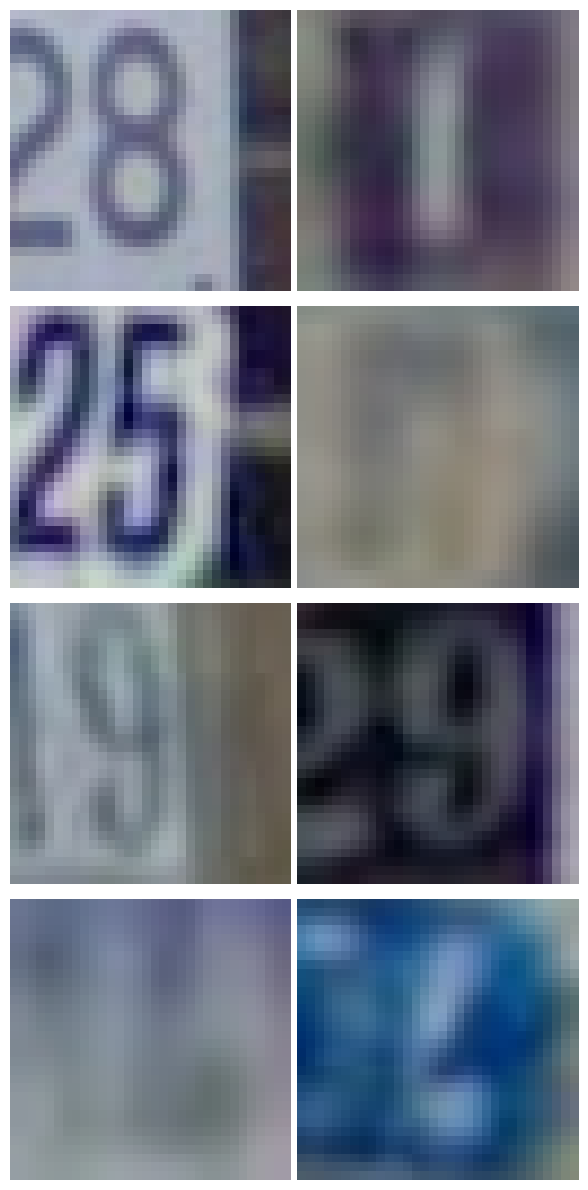

In [4]:
import numpy as np
import matplotlib.pyplot as plt

num_samples = train['X'].shape[-1]
idx = np.random.choice(num_samples, size=8, replace=False)

fig, axes = plt.subplots(4, 2, figsize=(6, 12))

for i, ax in enumerate(axes.flat):
    image = train['X'][:, :, :, idx[i]]
    
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

# 1. Inspect and Preprocess the dataset

Extracting the training and testing images an labels separadely.

In [5]:
X_train = train['X']
y_train = train['y']

X_test = test['X']
y_test = test['y']


Random sample of images and corresponding labels. 

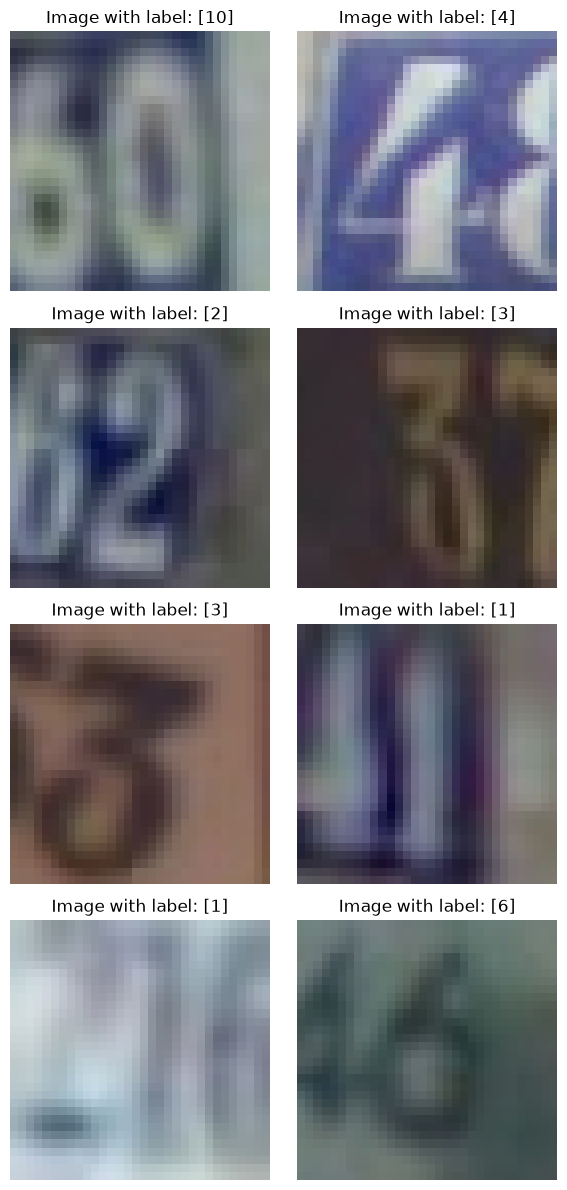

In [6]:
import numpy as np
import matplotlib.pyplot as plt

num_samples = X_train.shape[-1]
idx = np.random.choice(num_samples, size=8, replace=False)

fig, axes = plt.subplots(4, 2, figsize=(6, 12))

for i, ax in enumerate(axes.flat):
    image = X_train[:, :, :, idx[i]]
    ax.set_title(f"Image with label: {y_train[idx[i]]}")
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

Convertir las imágenes a escala de grises calculando el promedio en los canales.
Verificar la forma de las imágenes (32, 32, 1, N)

In [7]:

X_train_gray = np.mean(X_train, axis=2, keepdims=True)
X_test_gray = np.mean(X_test, axis=2, keepdims=True)

print("X_train_gray shape:", X_train_gray.shape)
print("X_test_gray shape:", X_test_gray.shape)

X_train_gray shape: (32, 32, 1, 73257)
X_test_gray shape: (32, 32, 1, 26032)


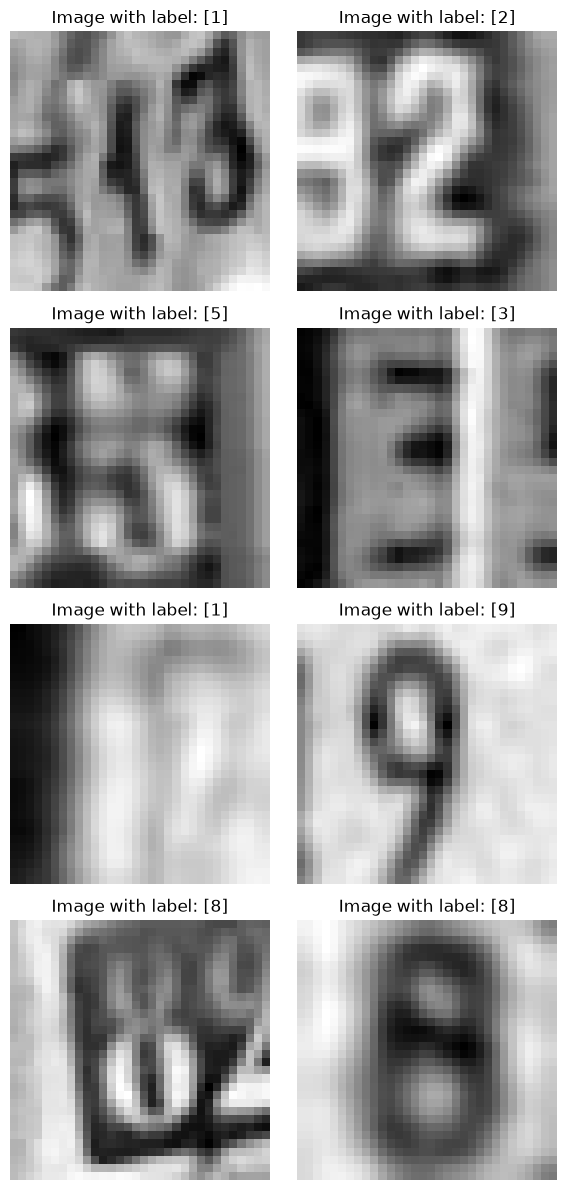

In [8]:
num_samples = X_train_gray.shape[-1]
idx = np.random.choice(num_samples, size=8, replace=False)

fig, axes = plt.subplots(4, 2, figsize=(6, 12))

for i, ax in enumerate(axes.flat):
    image = X_train_gray[:, :, :, idx[i]]
    ax.set_title(f"Image with label: {y_train[idx[i]]}")
    ax.imshow(image, cmap='gray')
    ax.axis("off")

plt.tight_layout()
plt.show()

# 2. MLP Neural Network Classifier

In [9]:
X_train_gray = np.transpose(X_train_gray, (3,0,1,2))

X_test_gray = np.transpose(X_test_gray, (3,0,1,2))

X_train_gray = X_train_gray/255.0
X_test_gray = X_test_gray/255.0


In [10]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2

model_mlp = Sequential([
    Flatten(input_shape=(32,32,1)),
    Dense(512, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(256, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(256, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(128, activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(128, activation='relu',
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])



c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\1 - Getting started with TensorFlow 2\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 777,738 (2.97 MB)

 Trainable params: 775,178 (2.96 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [12]:

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)

model_mlp.compile(optimizer=optimizer, metrics=['accuracy'],
              loss='sparse_categorical_crossentropy')



Definiendo los callbacks

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

path = 'checkpoint_MLP/MLP_checkpoint.weights.h5'

checkpoint = ModelCheckpoint(
    save_weights_only=True,
    save_best_only=True,
    filepath=path,
    monitor='val_loss',
    verbose=1
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)


callbacks_mlp = [checkpoint, early_stopping, reduce_lr]

In [14]:
y_train[y_train == 10] = 0
y_test[y_test == 10] = 0

history_mlp = model_mlp.fit(
    X_train_gray, 
    y_train,
    epochs = 30,
    batch_size=128,
    validation_split = 0.15,
    callbacks=callbacks_mlp,
    verbose=1
)

Epoch 1/30
485/487 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4160 - loss: 1.9846
Epoch 1: val_loss improved from None to 1.68535, saving model to checkpoint_MLP/MLP_checkpoint.weights.h5

Epoch 1: finished saving model to checkpoint_MLP/MLP_checkpoint.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4163 - loss: 1.9837 - val_accuracy: 0.5065 - val_loss: 1.6853 - learning_rate: 1.0000e-04
Epoch 2/30
481/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6483 - loss: 1.3088
Epoch 2: val_loss improved from 1.68535 to 1.49930, saving model to checkpoint_MLP/MLP_checkpoint.weights.h5

Epoch 2: finished saving model to checkpoint_MLP/MLP_checkpoint.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6486 - loss: 1.3081 - val_accuracy: 0.5878 - val_loss: 1.4993 - learning_rate: 1.0000e-04
Epoch 3/30
479/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7074 - loss: 1.1229
Epoch 3: val_loss improved from 1.49930 to 1.22967, saving model to checkpoint_MLP/ML

Learning Curves

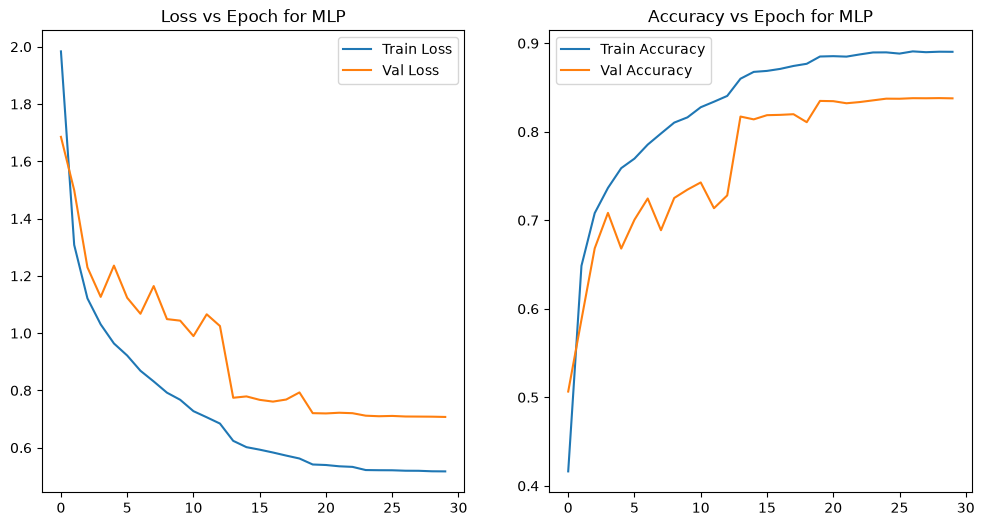

In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,6))

ax1.plot(history_mlp.history['loss'], label='Train Loss')
ax1.plot(history_mlp.history['val_loss'], label='Val Loss')
ax1.set_title('Loss vs Epoch for MLP')
ax1.legend()

ax2.plot(history_mlp.history['accuracy'], label='Train Accuracy')
ax2.plot(history_mlp.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy vs Epoch for MLP')
ax2.legend()


plt.show()




Model evaluation in test set

In [30]:
test_loss, test_acc = model_mlp.evaluate(X_test_gray, y_test, verbose=0)
print(f"Test Loss for MLP Model: {test_loss:.4f}")
print(f"Test Accuracy for MLP Model: {test_acc:.4f}")

Test Loss for MLP Model: 0.8046
Test Accuracy for MLP Model: 0.8119


# 3. CNN Neural Network Classifier

In [19]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (Dense, Flatten, BatchNormalization, Dropout,
                                     Conv2D, MaxPool2D)
from tensorflow.keras.regularizers import l2

model_cnn = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu',
           input_shape=(32,32,1)),
    MaxPool2D((2,2)),
    Conv2D(16, (2,2), padding='same', activation='relu'),
    MaxPool2D((2,2)),
    Flatten(),
    Dense(128, activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu',
              kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10, activation='softmax')
])


In [20]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 16)     │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,410 (595.35 KB)

 Trainable params: 151,898 (593.35 KB)

 Non-trainable params: 512 (2.00 KB)

In [21]:

from tensorflow.keras.optimizers import Adam

optimizer= Adam(learning_rate=0.001)

model_cnn.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])



Definiendo los callbacks

In [22]:

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


early_stopping_cnn = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

path = 'checkpoint_CNN/CNN_checkpoint.weights.h5'

checkpoint_cnn = ModelCheckpoint(
    filepath=path,
    save_weights_only=True,
    save_best_only=True,
    verbose=1,
    monitor='val_loss'
)

reduce_lr_cnn = ReduceLROnPlateau(
    patience=2,
    factor=0.3,
    monitor='val_loss',
    min_lr=1e-6,
    verbose=1
)


callbacks_cnn = [early_stopping_cnn, checkpoint_cnn, reduce_lr_cnn]

Fit the CNN Model

In [23]:

history_cnn = model_cnn.fit(
    X_train_gray, 
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.15,
    callbacks=callbacks_cnn,
    verbose=1
)


Epoch 1/30
481/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5489 - loss: 1.3888
Epoch 1: val_loss improved from None to 1.02231, saving model to checkpoint_CNN/CNN_checkpoint.weights.h5

Epoch 1: finished saving model to checkpoint_CNN/CNN_checkpoint.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5510 - loss: 1.3829 - val_accuracy: 0.6891 - val_loss: 1.0223 - learning_rate: 0.0010
Epoch 2/30
481/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7847 - loss: 0.6991
Epoch 2: val_loss improved from 1.02231 to 0.68825, saving model to checkpoint_CNN/CNN_checkpoint.weights.h5

Epoch 2: finished saving model to checkpoint_CNN/CNN_checkpoint.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7848 - loss: 0.6986 - val_accuracy: 0.7873 - val_loss: 0.6882 - learning_rate: 0.0010
Epoch 3/30
479/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8138 - loss: 0.6129
Epoch 3: val_loss improved from 0.68825 to 0.53882, saving model to checkpoint_CNN/CNN_checkp

Plotting Learning Curves

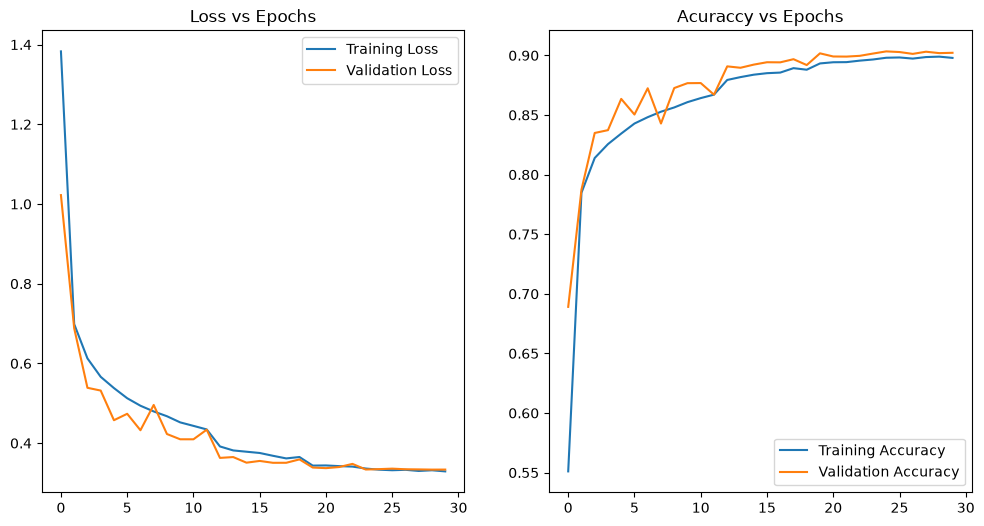

In [28]:
import matplotlib.pyplot as plt


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

ax1.plot(history_cnn.history['loss'], label='Training Loss')
ax1.plot(history_cnn.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss vs Epochs')
ax1.legend()

ax2.plot(history_cnn.history['accuracy'], label='Training Accuracy')
ax2.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Acuraccy vs Epochs')
ax2.legend()

plt.show()


Model Evaluation CNN in Test Set

In [ ]:
test_loss, test_acc = model_cnn.evaluate(X_test_gray, y_test, verbose=0)
print(f"Test Loss for CNN model: {test_loss:.4f}")
print(f"Test Accuracy for CNN model: {test_acc:.4f}")

Test Loss: 0.3644
Test Accuracy: 0.8907


# 4. Get Model Predictions

In [ ]:

new_model_MLP = Sequential([
    Flatten(input_shape=(32,32,1)),
    Dense(512, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(256, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(256, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(128, activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(128, activation='relu',
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

new_model_CNN = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu',
           input_shape=(32,32,1)),
    MaxPool2D((2,2)),
    Conv2D(16, (2,2), padding='same', activation='relu'),
    MaxPool2D((2,2)),
    Flatten(),
    Dense(128, activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu',
              kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10, activation='softmax')
])



c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\1 - Getting started with TensorFlow 2\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\1 - Getting started with TensorFlow 2\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:

optimizer= Adam(learning_rate=0.001)

new_model_MLP.load_weights('checkpoint_MLP/MLP_checkpoint.weights.h5')
new_model_MLP.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

new_model_CNN.load_weights('checkpoint_CNN/CNN_checkpoint.weights.h5')
new_model_CNN.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [36]:
test_loss, test_acc = new_model_MLP.evaluate(X_test_gray, y_test, verbose=0)
print(f"Test Loss for MLP model Loaded: {test_loss:.4f}")
print(f"Test Accuracy for MLP model Loaded: {test_acc:.4f}")


test_loss, test_acc = new_model_CNN.evaluate(X_test_gray, y_test, verbose=0)
print(f"Test Loss for CNN model Loaded: {test_loss:.4f}")
print(f"Test Accuracy for CNN model Loaded: {test_acc:.4f}")

Test Loss for MLP model Loaded: 0.8046
Test Accuracy for MLP model Loaded: 0.8119
Test Loss for CNN model Loaded: 0.3644
Test Accuracy for CNN model Loaded: 0.8907


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


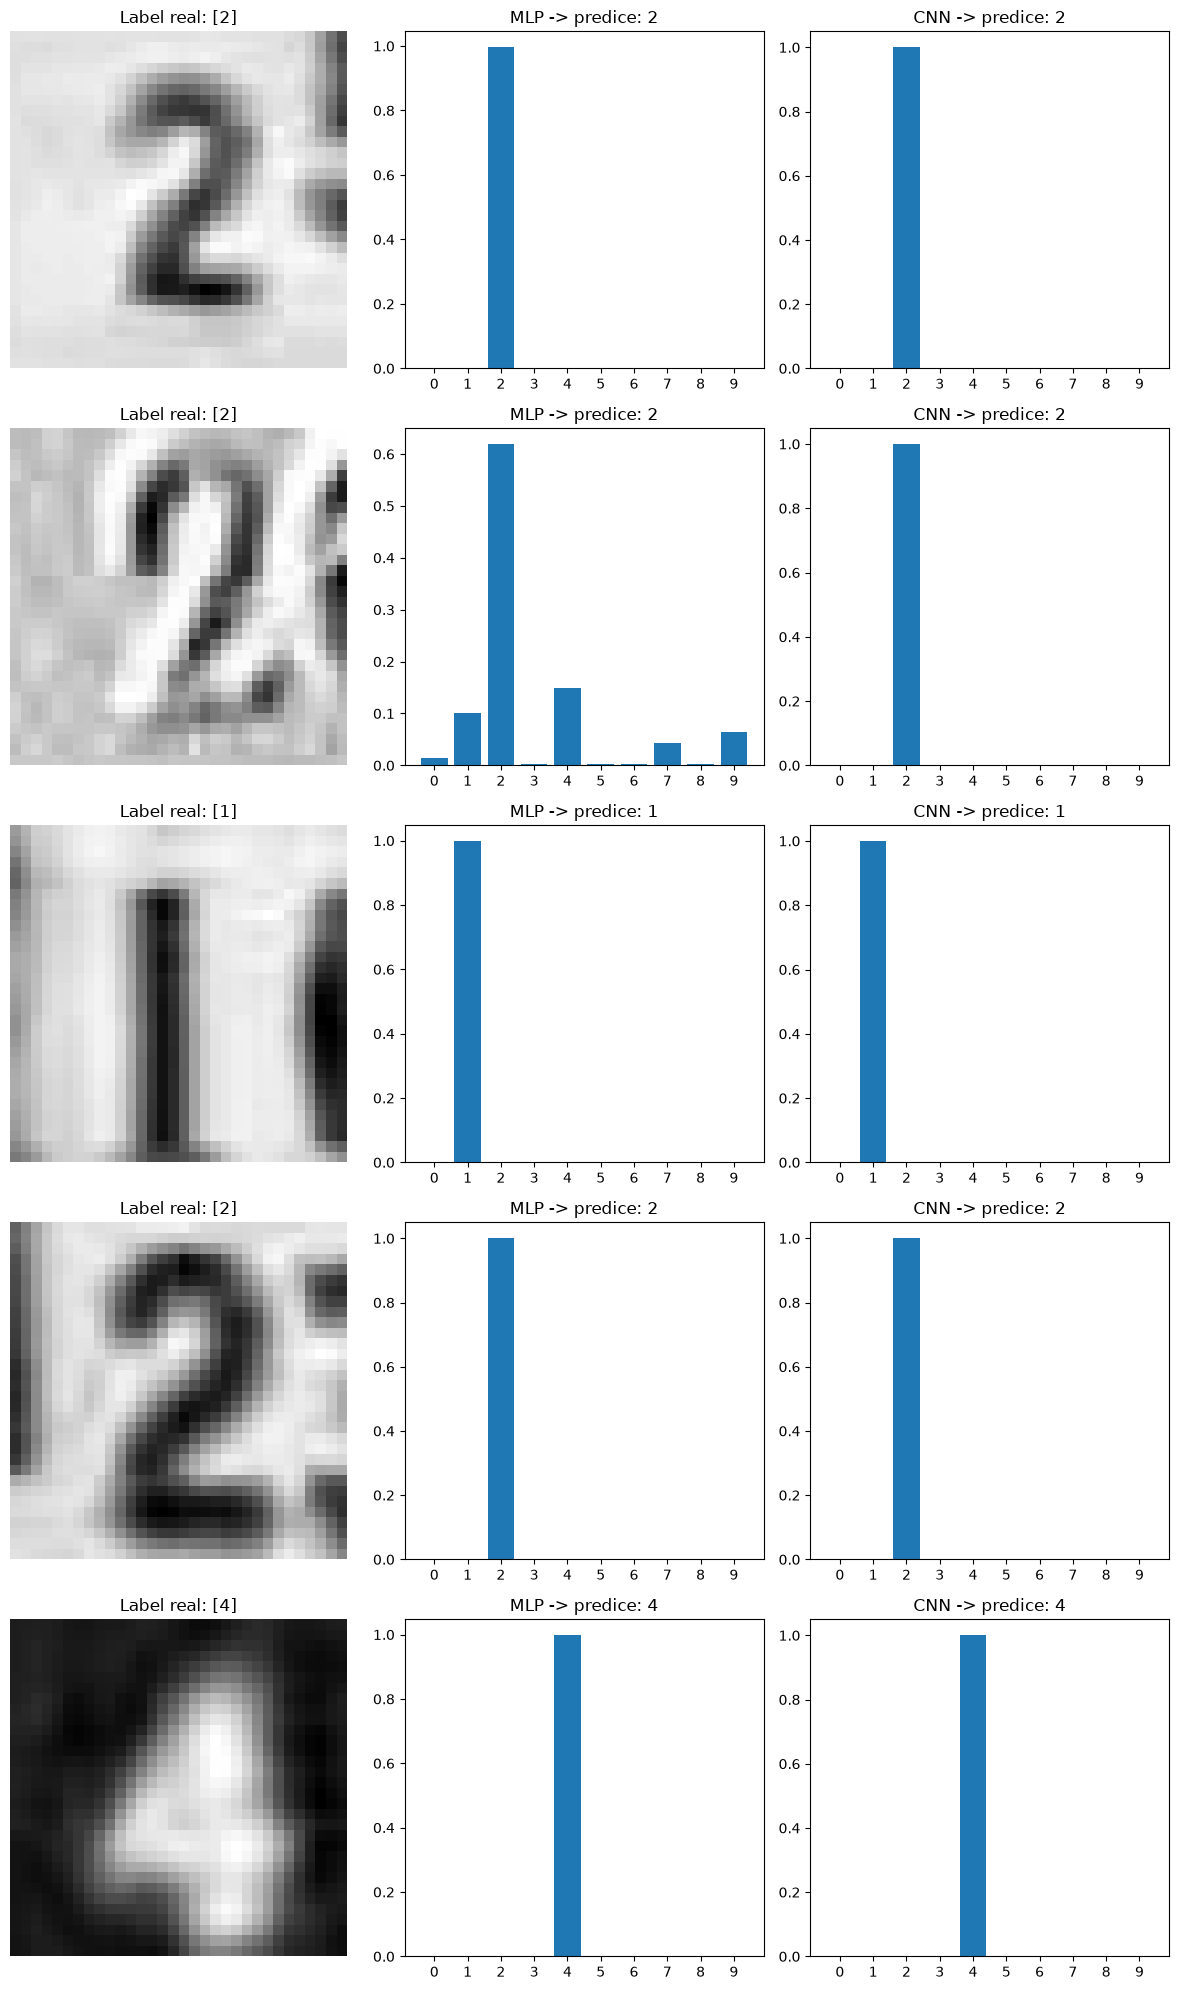

In [ ]:

num_samples = X_test_gray.shape[0] 
idx = np.random.choice(num_samples, size=5, replace=False)

# Obtener las predicciones (distribución de probabilidad) de cada modelo
pred_mlp = new_model_MLP.predict(X_test_gray[idx])
pred_cnn = new_model_CNN.predict(X_test_gray[idx])

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for i, sample_idx in enumerate(idx):
    # Columna 1: la imagen
    axes[i, 0].imshow(X_test_gray[sample_idx].squeeze(), cmap='gray')
    axes[i, 0].set_title(f"Real Label: {y_test[sample_idx]}")
    axes[i, 0].axis("off")

    # Columna 2: distribución de probabilidad del MLP
    pred_label_mlp = np.argmax(pred_mlp[i])
    axes[i, 1].bar(range(10), pred_mlp[i])
    axes[i, 1].set_title(f"MLP -> Predict: {pred_label_mlp}")
    axes[i, 1].set_xticks(range(10))

    # Columna 3: distribución de probabilidad del CNN
    pred_label_cnn = np.argmax(pred_cnn[i])
    axes[i, 2].bar(range(10), pred_cnn[i])
    axes[i, 2].set_title(f"CNN -> Predict: {pred_label_cnn}")
    axes[i, 2].set_xticks(range(10))

plt.tight_layout()
plt.show()